# 彩蛋课 · 先看看终点：让训练好的 AI 平衡倒立摆

> 这不是正式课程，是**信心补给站**。没有新知识点，不需要任何编程基础，
> 只要能打开 notebook、会按 `Shift+Enter`。
> **什么时候看**：装完环境（B-2 之后）就可以跑一遍；
> 以后任何时候学到怀疑人生，回来再跑一遍。

## 这节课你将体验到

1. 加载一个**已经训练好的 AI**（强化学习术语叫「策略 / policy」），
   看它在 CartPole（小车倒立摆）任务里稳稳拿满分；
2. 看懂这个任务的规则，以及「训练」到底是怎么回事——**没有人告诉 AI 怎么平衡**；
3. 知道你在课程的哪一周会亲手、从零开始训练出同样的东西。

## 1. 任务是什么：一根不能倒的杆子

CartPole 是强化学习界的「Hello World」：

- 一辆小车在轨道上左右移动，车上铰接着一根杆子；
- 杆子会倒，你（AI）唯一能做的就是**每一步决定小车向左还是向右推**；
- 杆子不倒，每撑一步得 1 分，撑满 500 步就是满分；倒了，本局结束。

人玩这个游戏靠手感。而这个 AI **没有一行代码写着「杆子往左倒就往左推」**——
它的全部本领，都是从几百万次「推倒 → 扣分 → 再试」里自己摸索出来的。
下面把它从存档里加载出来，看它表演。

In [1]:
# 本课程约定：小实验强制用 CPU 并限制线程数（不影响这台机器上别人的训练任务）
import os

os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["OMP_NUM_THREADS"] = "4"

from pathlib import Path

import torch
from stable_baselines3 import PPO

torch.set_num_threads(4)

PROJECT_ROOT = Path(os.getcwd()).parent.parent  # 项目根目录
model = PPO.load(PROJECT_ROOT / "checkpoints" / "w09_expert_cartpole.zip")
print("AI 加载成功，类型：", type(model).__name__)
print("这个 checkpoint 就是阶段一 W05–W09 会亲手训练并反复使用的那一位。")

AI 加载成功，类型： PPO
这个 checkpoint 就是阶段一 W05–W09 会亲手训练并反复使用的那一位。


In [2]:
# 让它玩 3 局，看看得分（满分 500）
import gymnasium as gym

env = gym.make("CartPole-v1")
for episode in range(3):
    obs, _ = env.reset(seed=episode)
    total = 0.0
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        total += reward
        if terminated or truncated:
            break
    print(f"第 {episode + 1} 局：{total:.0f} 分")
env.close()

第 1 局：500 分
第 2 局：500 分
第 3 局：500 分


GIF 已保存到: /data/wangf/robot_rl_learn/runs/00_basic/quickwin_cartpole.gif


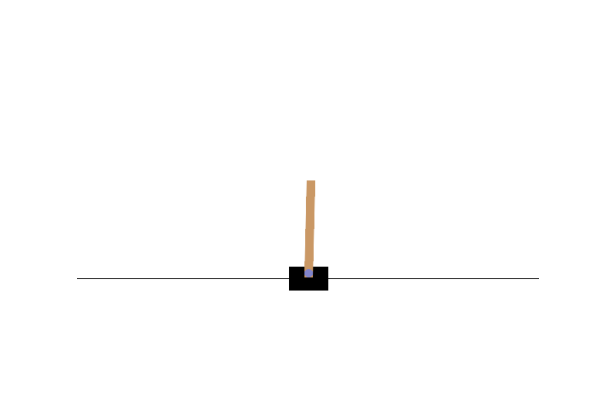

In [3]:
# 把其中一局渲染成 GIF，看看它长什么样
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage
from matplotlib import animation

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env.reset(seed=7)
frames = []
for _ in range(300):
    action, _ = model.predict(obs, deterministic=True)
    obs, _, terminated, truncated, _ = env.step(action)
    frames.append(env.render())
    if terminated or truncated:
        break
env.close()

fig = plt.figure(figsize=(6, 4))
plt.axis("off")
im = plt.imshow(frames[0])


def update(i):
    im.set_data(frames[i])
    return [im]


anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=40, blit=True)
gif_path = PROJECT_ROOT / "runs" / "00_basic" / "quickwin_cartpole.gif"
gif_path.parent.mkdir(parents=True, exist_ok=True)
anim.save(gif_path, writer="pillow", fps=25)
plt.close(fig)
print("GIF 已保存到:", gif_path)
IPyImage(filename=str(gif_path))

## 2. 它是怎么学会的？——奖励、试错、梯度

整个过程和教小狗握手惊人地相似：

1. **奖励信号**：杆子每多撑一步，AI 就得 1 分。这是人类给的**唯一**信息——
   没有规则、没有示范、没有物理公式；
2. **大胆试错**：AI 一开始瞎推，杆子秒倒，只得几分；
3. **趋利避害**：一种叫 PPO 的算法微调 AI 的「神经网路」，
   让「拿到高分的动作」下次更可能被做出来；
4. 重复几十万次之后，它找到了手感——就是你刚才看到的满分表演。

你在 **W05** 会逐行看懂 PPO 的超参数，并用**同一个算法**亲手复现这个专家；
在 **W09** 你还会让这个专家当「老师」，教一个只会模仿的「学生」AI（行为克隆）。

## 3. 所以，现在的你需要懂什么？

**什么都不用懂。** 这节课的三个 code cell 你一行都不需要理解——
它们只是提前揭开了终点的帘子。但请记住三个感觉：

- **AI 是能跑起来的实物**，不是论文里的公式——它就住在你课程的 `checkpoints/` 里；
- **训练 = 设计奖励 + 大量试错**——你后面学的所有算法，都是这两件事的不同做法；
- **从瞎推到满分是看得见的曲线**——W04 你会亲手画出这条学习曲线。

> 语法枯燥期（B01–B03）是本课程弃课率最高的地方。
> 觉得「学这些有什么用」的时候，回来按一次 `Shift+Enter`。

## ✏️ 小练习（不计分，玩就行）

**练习 1（难度 ★）换一局看看**
把评估 cell 里的 `seed=episode` 改成别的整数（比如 `seed=42`），重新运行。
AI 的表现有变化吗？这说明了什么？

**练习 2（难度 ★★）让 AI「紧张」一点**
把 `model.predict(obs, deterministic=True)` 改成 `deterministic=False`，跑 5 局。
分数还是满分吗？`deterministic` 这个开关大概控制着什么？

**练习 3（难度 ★★，思考题）**
这个 AI 没有学过物理、不知道「倒立摆动力学方程」，却能把杆子控制得比大多数人都稳。
用 3–4 句话回答：这和「人学骑自行车」有什么相同之处？
这正是本课程（强化学习）和传统控制理论（你们专业课会学的）最根本的分歧点。

<details>
<summary>👉 参考答案（先独立做，再点开）</summary>

**练习 1**
换个种子只是换杆子的初始微小扰动，专家级策略依然满分。
说明它学到的不是「背下某一局」，而是对**一整片初始状态**都稳健的技能——
这叫「泛化」，W07 会专门讨论怎么衡量它。

**练习 2**
`deterministic=False` 时 AI 按概率抽样动作，不再每次选最优动作，
分数会波动，偶尔会丢分。这个开关控制的是「** exploitation（利用）**
——只走最稳的路」还是「**exploration（探索）**——偶尔试试别的」。
训练时需要探索，考试时通常关掉。这对矛盾贯穿整门课，W01 就会正式见面。

**练习 3**
参考说法：人骑车也不知道力学方程，靠的是「身体倾斜 → 修正 → 反馈」的反复试错，
最后形成肌肉记忆；这个 AI 也一样，它的「肌肉记忆」存在神经网路的权重里。
相同点：都是通过**与环境的交互反馈**而非**显式规则**获得技能。
传统控制理论从「建模 → 推导控制律」出发，强化学习从「奖励 → 试错」出发——
当系统难以精确建模时（比如真实机器人），后者的优势就开始了，这也是阶段二
Sim2Real 要深入的主题。
</details>

## 延伸阅读

- [Hugging Face Deep RL Course 第 1 章](https://huggingface.co/learn/deep-rl-course/unit1/introduction)——「什么是强化学习」的最好入门读物（英文，配图极佳）；
- [OpenAI Spinning Up: RL 简介](https://spinningup.openai.com/en/latest/spinningup/rl_intro.html)——概念更系统的版本；
- [CartPole 环境官方文档](https://gymnasium.farama.org/environments/classic_control/cart_pole/)——W02 你会读懂这一页的每一行；
- 想立刻开始正式课程：回到 `docs/learning_path.md` 的自检清单，从你的入口周开始。

## 小结

- 你刚运行了一个训练好的强化学习策略：满分 500 分，住在 `checkpoints/` 里；
- 训练 = 奖励信号 + 大量试错 + 算法微调，没有人写规则；
- W04 第一次亲手训练，W05 复现这个专家，W09 让它当老师教学生；
- **把这节课加入收藏**。三个月后如果你在 PPO 超参数里怀疑人生，回来跑一遍。